# Annual glacier mass balance estimation from ASTER and MODIS albedo anomalies

Downscale the 20 year glacier mass balance derived from ASTER images (Huggonet et al., 2021, https://doi.org/10.6096/13) to annual glacier mass balance using MODIS glacier-wide albedo anomalies

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

## Input definition and preparation

In [2]:
aster_filename = './data/Huggonet_07_rgi60_pergla_rates.csv' # 7-Svalbard, 8-Scandinavia, 11-Alps
albedo_filename = './data/MOD10/All_glaciers/MOD10_albedo_JunSep_Svalbard.csv'
db_da = 5.56

ASTER mass balance from Huggonet et al., 2021

In [3]:
aster_mb = pd.read_csv(aster_filename, usecols=['rgiid', 'period', 'dmdtda'], index_col=['rgiid', 'period'])

aster_mb = aster_mb.loc[(slice(None), [f'{y}-01-01_{y+1}-01-01' for y in range(2000, 2020)]), :]
aster_mb.dropna(inplace=True)

aster_mb = aster_mb.rename(index=lambda x: int(x[:4]), level='period')

aster_mb = aster_mb.rename_axis(index={'rgiid': 'RGI60_ID', 'period': 'YEAR'})
aster_mb = aster_mb.rename(columns={'dmdtda': 'ASTER_gmb'})
aster_mb

ASTER_gmb
RGI60_ID       YEAR           
RGI60-07.00001 2000    -0.7163
               2001    -0.8184
               2002    -0.7629
               2003    -0.5035
               2004    -0.4949
...                        ...
RGI60-07.01615 2015    -0.1121
               2016    -0.1735
               2017     0.0346
               2018    -0.1026
               2019    -0.4368

[32260 rows x 1 columns]

MOD10 albedo

In [4]:
MOD10_albedo = pd.read_csv(albedo_filename, index_col=0)

MOD10_albedo = MOD10_albedo.transpose().stack().rename('MOD10_albedo')
MOD10_albedo.index.names = ['RGI60_ID', 'YEAR']
MOD10_albedo

RGI60_ID        YEAR
RGI60-07.01012  2000    0.455232
                2001    0.345275
                2002    0.246533
                2003    0.319610
                2004    0.546330
                          ...   
RGI60-07.01364  2020    0.605744
                2021    0.590541
                2022    0.455310
                2023    0.517092
                2024    0.445978
Name: MOD10_albedo, Length: 32033, dtype: float64

In [5]:
valid_id = MOD10_albedo.groupby(level=0).apply(
    lambda x: set(x.index.get_level_values("YEAR")) == set(range(2000, 2025))
)
valid_id = valid_id.loc[valid_id==True].index

MOD10_albedo = MOD10_albedo.loc[valid_id]

MOD10_albedo

RGI60_ID        YEAR
RGI60-07.00001  2000    0.502389
                2001    0.394430
                2002    0.360725
                2003    0.325480
                2004    0.476432
                          ...   
RGI60-07.01587  2020    0.702325
                2021    0.640115
                2022    0.713826
                2023    0.551897
                2024    0.559810
Name: MOD10_albedo, Length: 31850, dtype: float64

Concatenate

In [6]:
df = pd.concat([aster_mb, MOD10_albedo], axis=1).sort_index(level=['RGI60_ID', 'YEAR'])
df = df.dropna(subset='MOD10_albedo')
df

ASTER_gmb  MOD10_albedo
RGI60_ID       YEAR                         
RGI60-07.00001 2000    -0.7163      0.502389
               2001    -0.8184      0.394430
               2002    -0.7629      0.360725
               2003    -0.5035      0.325480
               2004    -0.4949      0.476432
...                        ...           ...
RGI60-07.01587 2020        NaN      0.702325
               2021        NaN      0.640115
               2022        NaN      0.713826
               2023        NaN      0.551897
               2024        NaN      0.559810

[31850 rows x 2 columns]

For Svalbard remove the marine terminating and surging

In [13]:
import geopandas as gpd

rgi60_filename = './data/rgi60/07_rgi60_Svalbard.shp'
rgi = gpd.read_file(rgi60_filename, ignore_geometry=True)

In [14]:
len(rgi)

1615

In [16]:
rgi.loc[rgi['Area'] > 0.5]

,RGIId,GLIMSId,BgnDate,EndDate,CenLon,CenLat,O1Region,O2Region,Area,Zmin,...,Slope,Aspect,Lmax,Status,Connect,Form,TermType,Surging,Linkages,Name
0,RGI60-07.00001,G017035E76705N,20080901,-9999999,17.03470,76.7052,7,1,0.597,142,...,16.7,204,1388,0,0,0,0,0,9,None
1,RGI60-07.00002,G016189E76787N,20080901,-9999999,16.18910,76.7872,7,1,0.581,234,...,18.3,277,1658,0,0,0,0,0,9,Bungebreen
3,RGI60-07.00004,G015993E76942N,20080901,-9999999,15.99320,76.9423,7,1,1.044,665,...,13.8,62,1075,0,0,0,0,0,9,None
5,RGI60-07.00006,G016429E76938N,20080901,-9999999,16.42890,76.9375,7,1,13.618,111,...,12.6,336,8187,0,0,0,1,0,9,Chomjakovbreen
6,RGI60-07.00007,G016426E76966N,20080901,-9999999,16.42630,76.9661,7,1,0.559,143,...,16.3,328,1536,0,0,0,0,0,9,Mendelejevbreen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1582,RGI60-07.01583,G351932E71082N,19759999,-9999999,-8.06777,71.0824,7,2,4.465,0,...,23.8,107,5162,0,0,0,1,9,9,NO4W00110016 Griegbreen
1583,RGI60-07.01584,G351925E71070N,19759999,-9999999,-8.07534,71.0701,7,2,4.909,0,...,22.4,95,4070,0,0,0,1,9,9,NO4W00110017 Willebreen
1584,RGI60-07.01585,G351938E71056N,19759999,-9999999,-8.06200,71.0555,7,2,5.475,255,...,15.9,82,4462,0,0,0,0,9,9,NO4W00110018 Petersenbreen
1585,RGI60-07.01586,G351906E71041N,19759999,-9999999,-8.09447,71.0407,7,2,9.016,332,...,11.9,148,4076,0,0,0,0,9,9,NO4W00110019 Fotherbybreen


In [10]:
valid_rgiId = rgi.loc[(rgi['TermType'] == 0) & (rgi['Surging'] != 3), 'RGIId']
valid_rgiId

0       RGI60-07.00001
1       RGI60-07.00002
2       RGI60-07.00003
3       RGI60-07.00004
4       RGI60-07.00005
             ...      
1610    RGI60-07.01611
1611    RGI60-07.01612
1612    RGI60-07.01613
1613    RGI60-07.01614
1614    RGI60-07.01615
Name: RGIId, Length: 1407, dtype: object

In [11]:
df[df.index.get_level_values("RGI60_ID").isin(set(valid_rgiId))]

ASTER_gmb  MOD10_albedo
RGI60_ID       YEAR                         
RGI60-07.00001 2000    -0.7163      0.502389
               2001    -0.8184      0.394430
               2002    -0.7629      0.360725
               2003    -0.5035      0.325480
               2004    -0.4949      0.476432
...                        ...           ...
RGI60-07.01587 2020        NaN      0.702325
               2021        NaN      0.640115
               2022        NaN      0.713826
               2023        NaN      0.551897
               2024        NaN      0.559810

[26700 rows x 2 columns]

In [12]:
len(df.index.get_level_values(0).unique())

1274

Create the dataframe of the average albedo and mass balance in the reference period 2000-2019

In [13]:
df_avg = df.loc[(slice(None), slice(2000, 2019)), :].groupby(level='RGI60_ID', group_keys=False).mean()
df_avg

,ASTER_gmb,MOD10_albedo
RGI60_ID,,
RGI60-07.00001,-0.326755,0.461121
RGI60-07.00002,-0.007260,0.394261
RGI60-07.00004,-0.085440,0.533821
RGI60-07.00006,-0.448185,0.518980
RGI60-07.00007,-0.032595,0.420137
...,...,...
RGI60-07.01583,0.018345,0.504030
RGI60-07.01584,0.055515,0.461097
RGI60-07.01585,-0.012205,0.502071


Compute the annual mass balance

In [14]:
amb = df_avg['ASTER_gmb'] + (df['MOD10_albedo'] - df_avg['MOD10_albedo']) * db_da
amb.name = 'mass_balance'

In [15]:
amb

RGI60_ID        YEAR
RGI60-07.00001  2000   -0.097304
                2001   -0.697559
                2002   -0.884958
                2003   -1.080918
                2004   -0.241626
                          ...   
RGI60-07.01587  2020    0.064497
                2021   -0.281390
                2022    0.128442
                2023   -0.771880
                2024   -0.727888
Name: mass_balance, Length: 31850, dtype: float64

In [16]:
amb.to_csv('./data/annual_mass_balance/Svalbard.csv')

 ## Plot

In [17]:
amb.groupby(level='YEAR', group_keys=False).std()

YEAR
2000    0.388641
2001    0.385063
2002    0.364733
2003    0.393798
2004    0.353411
2005    0.420187
2006    0.400687
2007    0.392751
2008    0.375362
2009    0.347434
2010    0.405787
2011    0.430753
2012    0.395457
2013    0.436496
2014    0.372796
2015    0.428026
2016    0.453182
2017    0.379399
2018    0.398150
2019    0.483985
2020    0.501813
2021    0.434656
2022    0.436154
2023    0.411389
2024    0.448370
Name: mass_balance, dtype: float64

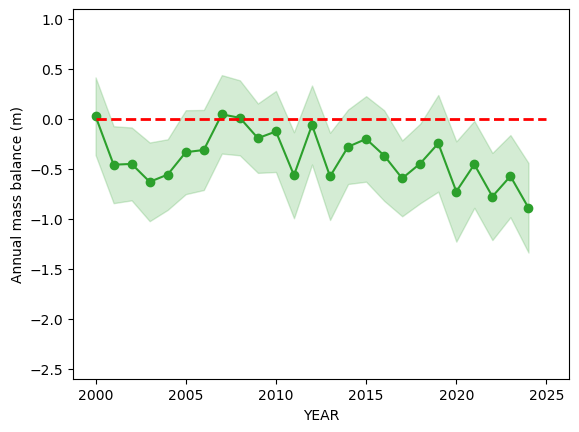

In [18]:
amb_avg = amb.groupby(level='YEAR', group_keys=False).mean()
amb_std = amb.groupby(level='YEAR', group_keys=False).std()

ax = amb_avg.plot(marker='o', color='C2')

plt.fill_between(
    amb_avg.index,
    amb_avg - amb_std,
    amb_avg + amb_std,
    color='C2',
    alpha=0.2,
)

ax.set_ylim(-2.6, 1.1)

ax.plot([2000, 2025], [0, 0], color='red', linestyle='--', linewidth=2)

plt.ylabel("Annual mass balance (m)")

plt.savefig("Svalbard_noSurge_noMarine_TimeSeries.png", dpi=600)
plt.show()


In [3]:
amb_avg - amb_std

NameError: name 'amb_avg' is not defined

## check for validation

In [10]:
wgms_filename = './data/WGMS/wgms_MB_Scandinavia.csv'

In [11]:
wgms = pd.read_csv(wgms_filename, usecols=['RGI60_ID', 'YEAR', 'ANNUAL_BALANCE'], index_col=['RGI60_ID', 'YEAR'])
wgms.rename(columns={'ANNUAL_BALANCE': 'WGMS_gmb'}, inplace=True)
wgms = wgms/1000 # Convert from mm to m
wgms

WGMS_gmb
RGI60_ID       YEAR          
RGI60-08.02666 2000     1.135
               2001    -2.523
               2002    -2.072
               2003    -3.028
               2004    -0.484
...                       ...
RGI60-08.00210 2009    -1.710
               2010    -1.060
               2011    -1.820
               2012     0.830
               2015     0.610

[411 rows x 1 columns]

In [12]:
amb.name = 'MOD10_albedo_gmb'
df_val = pd.concat([wgms, amb], axis=1).sort_index(level=['RGI60_ID', 'YEAR']).dropna()
df_val

WGMS_gmb  MOD10_albedo_gmb
RGI60_ID       YEAR                            
RGI60-08.00006 2000    -0.312         -0.214313
               2001    -1.730         -0.816756
               2002    -1.830         -0.474845
               2003    -1.780          0.406518
               2005    -0.350         -1.151443
...                       ...               ...
RGI60-08.02969 2013    -0.234         -0.661244
               2014    -0.094         -0.583383
               2015     1.991          0.585839
               2016     0.701         -0.266956
               2017    -0.350         -0.209729

[411 rows x 2 columns]

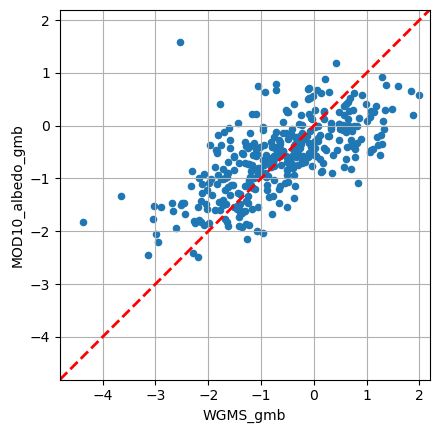

In [13]:
df_plot = df_val.loc[(slice(None), slice(2000, 2019)), :]

ax = df_plot.plot.scatter(x='WGMS_gmb', y='MOD10_albedo_gmb')

ax_min = df_plot[['WGMS_gmb', 'MOD10_albedo_gmb']].min().min() * 1.1
ax_max = df_plot[['WGMS_gmb', 'MOD10_albedo_gmb']].max().max() * 1.1

ax.set_xlim(ax_min, ax_max)
ax.set_ylim(ax_min, ax_max)
ax.set_aspect('equal', adjustable='box')

ax.plot([ax_min, ax_max], [ax_min, ax_max], color='red', linestyle='--', linewidth=2)
plt.grid(True)

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [15]:
mean_absolute_error(df_plot['WGMS_gmb'], df_plot['MOD10_albedo_gmb'])

0.6106725599213739

In [16]:
np.sqrt(mean_squared_error(df_plot['WGMS_gmb'], df_plot['MOD10_albedo_gmb']))

0.7884159301078545

In [17]:
r2_score(df_plot['WGMS_gmb'], df_plot['MOD10_albedo_gmb'])

0.43667011950682677